In [1]:
# =========================================================
# Handwritten Digit Recognition using CNN (MNIST)
# Deep Learning Project - PyTorch Version
# =========================================================

# =========================================================
# 1. Import Libraries
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix, classification_report

# Device Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using Device:", device)



Using Device: cuda


In [16]:
# =========================================================
# 2. Load MNIST Dataset
# =========================================================

transform = transforms.Compose([

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5,),
        (0.5,)
    )
])

full_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# =========================================================
# Take Only 6000 Samples
# =========================================================

subset_dataset = torch.utils.data.Subset(
    full_dataset,
    range(6000)
)

# =========================================================
# Split Dataset
# =========================================================

train_size = 5000
val_size = 1000

train_dataset, val_dataset = torch.utils.data.random_split(
    subset_dataset,
    [train_size, val_size]
)

# =========================================================
# Test Dataset
# =========================================================

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# =========================================================
# Data Loaders
# =========================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("\nDataset Loaded Successfully")

print("Training Samples:", len(train_dataset))

print("Validation Samples:", len(val_dataset))

print("Testing Samples:", len(test_dataset))


Dataset Loaded Successfully
Training Samples: 5000
Validation Samples: 1000
Testing Samples: 10000


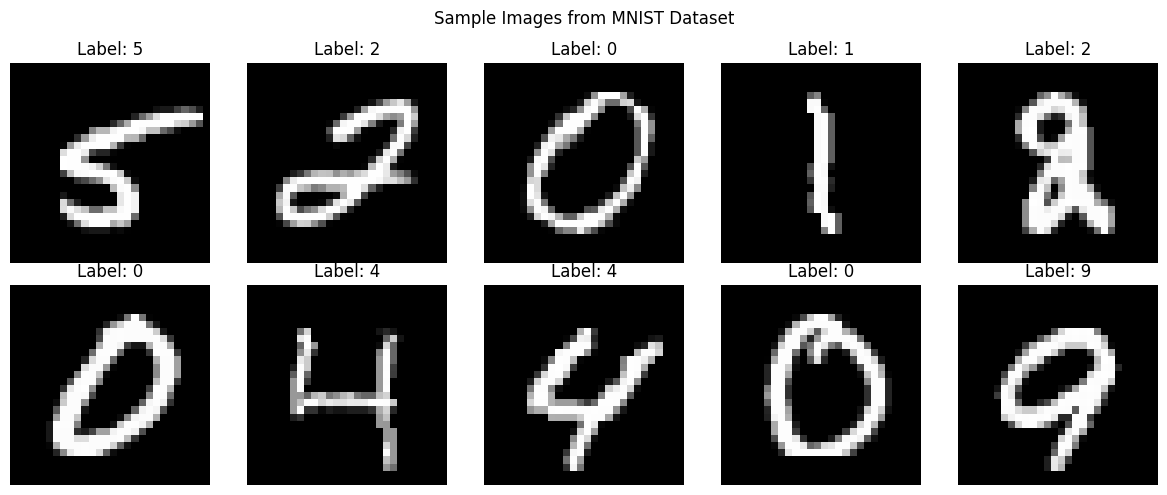

In [17]:
# =========================================================
# 3. Display Sample Images
# =========================================================

plt.figure(figsize=(12,5))

for i in range(10):

    image, label = train_dataset[i]

    plt.subplot(2,5,i+1)
    plt.imshow(image.squeeze(), cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')

plt.suptitle("Sample Images from MNIST Dataset")
plt.tight_layout()
plt.show()



In [18]:
# =========================================================
# 4. Build CNN Model
# =========================================================

class CNNModel(nn.Module):

    def __init__(self):
        super(CNNModel, self).__init__()

        self.conv_layers = nn.Sequential(

            # First CNN Block
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            # Second CNN Block
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):

        x = self.conv_layers(x)
        x = self.fc_layers(x)

        return x



In [19]:
# =========================================================
# 5. Training Function
# =========================================================

def train_model(model, optimizer_name, optimizer, epochs=10):

    criterion = nn.CrossEntropyLoss()

    train_losses = []
    train_accuracies = []

    for epoch in range(epochs):

        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = correct / total

        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        print(
            f"{optimizer_name} | Epoch [{epoch+1}/{epochs}] "
            f"Loss: {epoch_loss:.4f} "
            f"Accuracy: {epoch_acc*100:.2f}%"
        )

    return train_losses, train_accuracies


In [20]:
# =========================================================
# 6. Evaluation Function
# =========================================================

def evaluate_model(model):

    model.eval()

    correct = 0
    total = 0

    predictions = []
    actuals = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            predictions.extend(predicted.cpu().numpy())
            actuals.extend(labels.cpu().numpy())

    accuracy = correct / total

    return accuracy, predictions, actuals



In [21]:
# =========================================================
# 7. Experiment 1 - Adam Optimizer
# =========================================================

model_adam = CNNModel().to(device)

optimizer_adam = optim.Adam(
    model_adam.parameters(),
    lr=0.001
)

adam_losses, adam_accuracies = train_model(
    model_adam,
    "Adam",
    optimizer_adam
)

acc_adam, pred_adam, actual_adam = evaluate_model(model_adam)

print(f"\nAdam Test Accuracy: {acc_adam*100:.2f}%")


Adam | Epoch [1/10] Loss: 1.1189 Accuracy: 62.66%
Adam | Epoch [2/10] Loss: 0.5468 Accuracy: 82.40%
Adam | Epoch [3/10] Loss: 0.3971 Accuracy: 87.88%
Adam | Epoch [4/10] Loss: 0.3358 Accuracy: 90.06%
Adam | Epoch [5/10] Loss: 0.2877 Accuracy: 91.18%
Adam | Epoch [6/10] Loss: 0.2505 Accuracy: 92.16%
Adam | Epoch [7/10] Loss: 0.2259 Accuracy: 92.92%
Adam | Epoch [8/10] Loss: 0.2250 Accuracy: 93.14%
Adam | Epoch [9/10] Loss: 0.2000 Accuracy: 94.30%
Adam | Epoch [10/10] Loss: 0.1839 Accuracy: 93.72%

Adam Test Accuracy: 97.18%


In [22]:
# =========================================================
# 8. Experiment 2 - SGD Optimizer
# =========================================================

model_sgd = CNNModel().to(device)

optimizer_sgd = optim.SGD(
    model_sgd.parameters(),
    lr=0.01,
    momentum=0.9
)

sgd_losses, sgd_accuracies = train_model(
    model_sgd,
    "SGD",
    optimizer_sgd
)

acc_sgd, pred_sgd, actual_sgd = evaluate_model(model_sgd)

print(f"\nSGD Test Accuracy: {acc_sgd*100:.2f}%")


SGD | Epoch [1/10] Loss: 1.0412 Accuracy: 64.86%
SGD | Epoch [2/10] Loss: 0.4954 Accuracy: 83.90%
SGD | Epoch [3/10] Loss: 0.3765 Accuracy: 87.76%
SGD | Epoch [4/10] Loss: 0.3259 Accuracy: 89.50%
SGD | Epoch [5/10] Loss: 0.2906 Accuracy: 91.30%
SGD | Epoch [6/10] Loss: 0.2459 Accuracy: 92.34%
SGD | Epoch [7/10] Loss: 0.2233 Accuracy: 93.00%
SGD | Epoch [8/10] Loss: 0.2251 Accuracy: 93.10%
SGD | Epoch [9/10] Loss: 0.1922 Accuracy: 93.60%
SGD | Epoch [10/10] Loss: 0.1917 Accuracy: 94.30%

SGD Test Accuracy: 96.66%


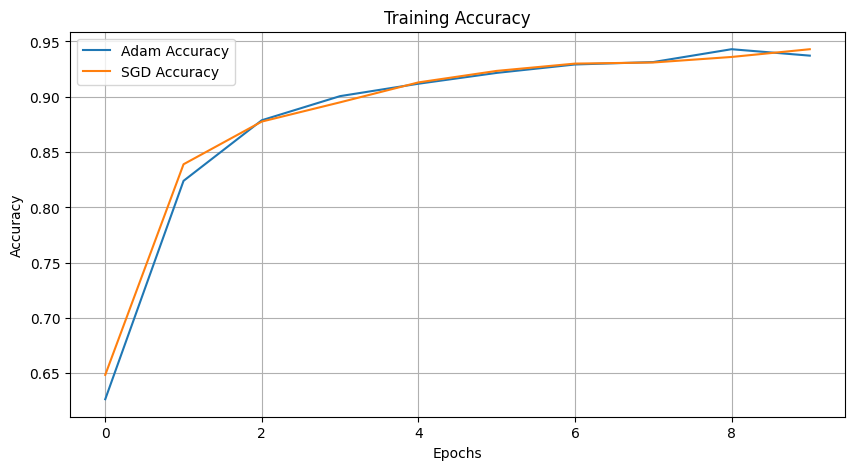

In [23]:
# =========================================================
# 9. Plot Accuracy Curves
# =========================================================

plt.figure(figsize=(10,5))

plt.plot(adam_accuracies, label='Adam Accuracy')
plt.plot(sgd_accuracies, label='SGD Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.legend()
plt.grid(True)

plt.show()



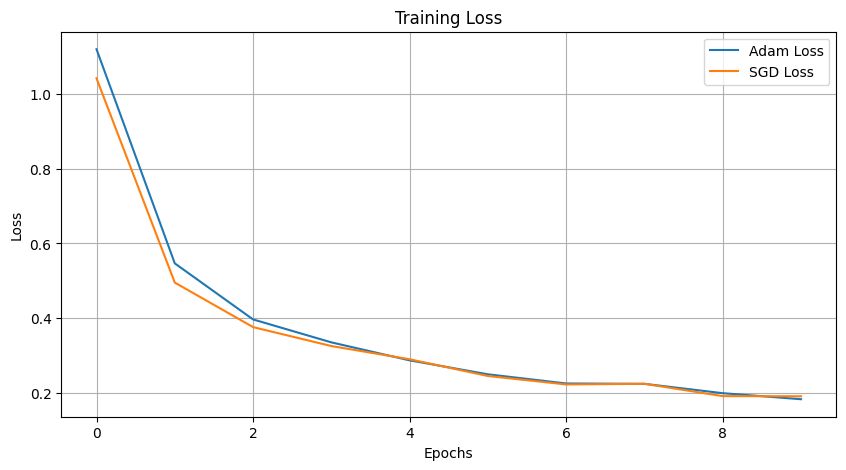

In [24]:
# =========================================================
# 10. Plot Loss Curves
# =========================================================

plt.figure(figsize=(10,5))

plt.plot(adam_losses, label='Adam Loss')
plt.plot(sgd_losses, label='SGD Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.grid(True)

plt.show()

In [25]:
# =========================================================
# 11. Select Best Model
# =========================================================

if acc_adam > acc_sgd:
    best_model = model_adam
    best_name = "Adam"
    y_pred = pred_adam
else:
    best_model = model_sgd
    best_name = "SGD"
    y_pred = pred_sgd

print("\nBest Model:", best_name)


Best Model: Adam


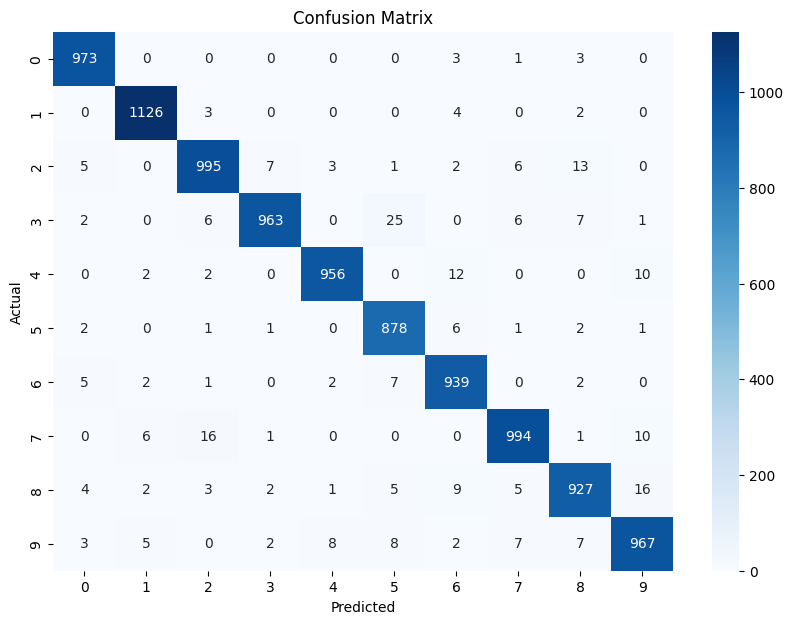

In [26]:
# =========================================================
# 12. Confusion Matrix
# =========================================================

cm = confusion_matrix(actual_adam, y_pred)

plt.figure(figsize=(10,7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()



In [27]:
# =========================================================
# 13. Classification Report
# =========================================================

print("\nClassification Report\n")

print(classification_report(
    actual_adam,
    y_pred
))


Classification Report

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.96      0.97      1032
           3       0.99      0.95      0.97      1010
           4       0.99      0.97      0.98       982
           5       0.95      0.98      0.97       892
           6       0.96      0.98      0.97       958
           7       0.97      0.97      0.97      1028
           8       0.96      0.95      0.96       974
           9       0.96      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



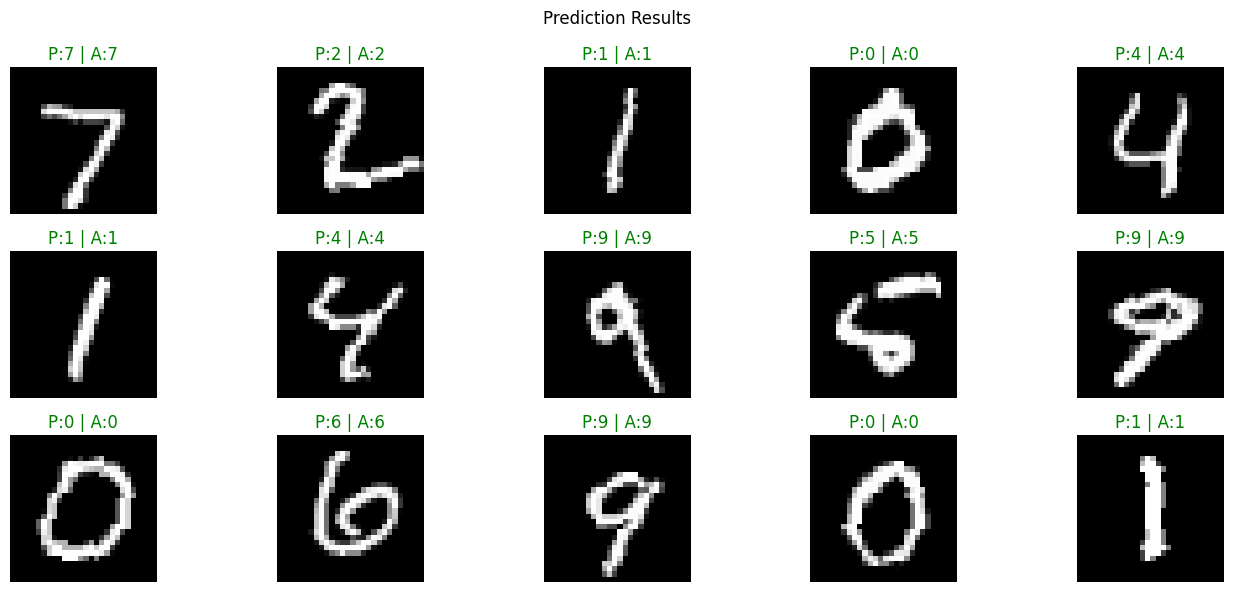

In [28]:
# =========================================================
# 14. Visualize Predictions
# =========================================================

plt.figure(figsize=(14,6))

for i in range(15):

    image, label = test_dataset[i]

    image_input = image.unsqueeze(0).to(device)

    best_model.eval()

    with torch.no_grad():
        output = best_model(image_input)
        _, predicted = torch.max(output, 1)

    predicted = predicted.item()

    plt.subplot(3,5,i+1)

    plt.imshow(image.squeeze(), cmap='gray')

    color = 'green' if predicted == label else 'red'

    plt.title(
        f"P:{predicted} | A:{label}",
        color=color
    )

    plt.axis('off')

plt.suptitle("Prediction Results")
plt.tight_layout()
plt.show()

In [29]:
# =========================================================
# 15. Final Comparison Table
# =========================================================

print("\n======================================")
print("FINAL RESULTS COMPARISON")
print("======================================")

print("\nExperiment 1 - Adam")
print("Accuracy:", round(acc_adam*100,2), "%")

print("\nExperiment 2 - SGD")
print("Accuracy:", round(acc_sgd*100,2), "%")


FINAL RESULTS COMPARISON

Experiment 1 - Adam
Accuracy: 97.18 %

Experiment 2 - SGD
Accuracy: 96.66 %


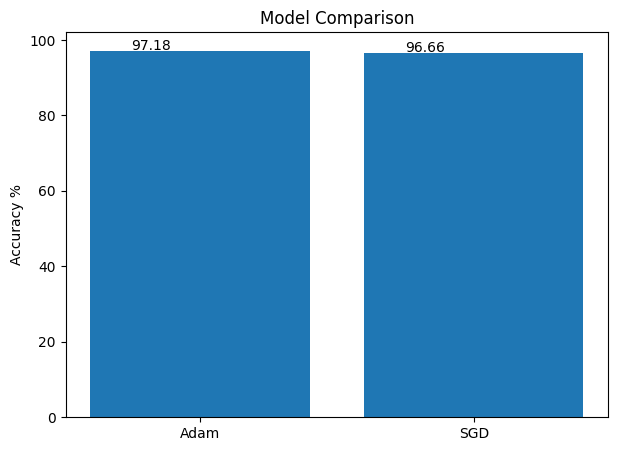

In [30]:
# =========================================================
# 16. Accuracy Comparison Chart
# =========================================================

models_names = ['Adam', 'SGD']
accuracies = [acc_adam*100, acc_sgd*100]

plt.figure(figsize=(7,5))

bars = plt.bar(models_names, accuracies)

plt.ylabel("Accuracy %")
plt.title("Model Comparison")

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + 0.15,
        yval + 0.1,
        round(yval,2)
    )

plt.show()

In [31]:
# =========================================================
# 17. Final Summary
# =========================================================

winner = "Adam" if acc_adam > acc_sgd else "SGD"

print("\n======================================")
print("PROJECT SUMMARY")
print("======================================")

print("Dataset  : MNIST")
print("Task     : Image Classification")
print("Model    : CNN")

print("\nAdam Accuracy :", round(acc_adam*100,2), "%")
print("SGD Accuracy  :", round(acc_sgd*100,2), "%")

print("\nBest Optimizer:", winner)

print("\nProject Completed Successfully")



PROJECT SUMMARY
Dataset  : MNIST
Task     : Image Classification
Model    : CNN

Adam Accuracy : 97.18 %
SGD Accuracy  : 96.66 %

Best Optimizer: Adam

Project Completed Successfully
